# TP006 — Fotografía Digital
## Parte 1: Cámara Oscura Estenopeica
### Procesamiento: Rotación → Recorte automático → Ecualización HSV

**Alumno:** Farfán Eduardo  
**Materia:** Procesamiento Digital de Imágenes  
**Fecha:** 13 Mayo 2026

---
##  Importaciones y configuración

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ipywidgets import interact, IntSlider
%matplotlib inline

# ── Rutas ──────────────────────────────────────────────────────────────────
carpeta_originales = Path("imagenes/originales")
carpeta_procesadas = Path("imagenes/procesadas")
carpeta_procesadas.mkdir(parents=True, exist_ok=True)

# ── Nombre de tu imagen de cámara oscura ───────────────────────────────────
NOMBRE_IMAGEN = "camara_oscura.jpg"   # ← cambiá este nombre por el tuyo

print("Carpeta originales:", carpeta_originales.resolve())
print("Carpeta procesadas:", carpeta_procesadas.resolve())

Carpeta originales: /home/farfaneduardo/Documentos/Proyectos/farfan-eduardo-pdi-1c-2026/006/003 - LAB/imagenes/originales
Carpeta procesadas: /home/farfaneduardo/Documentos/Proyectos/farfan-eduardo-pdi-1c-2026/006/003 - LAB/imagenes/procesadas


---
## 1. Funciones auxiliares


In [2]:
def cargar_rgb(ruta):
    """Lee una imagen y la devuelve en RGB."""
    img_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo leer: {ruta}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def guardar_rgb(ruta, img_rgb):
    """Guarda una imagen RGB en disco."""
    cv2.imwrite(str(ruta), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))


def mostrar_imagen(img, titulo=""):
    """Muestra una imagen con título."""
    plt.figure(figsize=(7, 6), constrained_layout=True)
    cmap = "gray" if img.ndim == 2 else None
    plt.imshow(img, cmap=cmap)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("on")
    plt.show()


def mostrar_comparacion(img_izq, img_der, titulo_izq, titulo_der):
    """Comparación lado a lado de dos imágenes."""
    fig, ejes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    for ax, img, titulo in zip(ejes, [img_izq, img_der], [titulo_izq, titulo_der]):
        cmap = "gray" if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(titulo, fontweight="bold", loc="left")
        ax.axis("off")
    plt.show()


def mostrar_histograma(img, titulo="Histograma"):
    """Histograma en escala de grises de una imagen color o gris."""
    gris = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hist, bordes = np.histogram(gris.flatten(), bins=256, range=[0, 256])
    plt.figure(figsize=(10, 3), constrained_layout=True)
    plt.plot(bordes[:-1], hist, color="steelblue")
    plt.fill_between(bordes[:-1], hist, alpha=0.3, color="steelblue")
    plt.title(titulo, fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Píxeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_histogramas_comparados(img_antes, img_despues,
                                    titulo_antes="Antes",
                                    titulo_despues="Después"):
    """Muestra dos histogramas uno al lado del otro para comparar."""
    fig, ejes = plt.subplots(1, 2, figsize=(13, 3), constrained_layout=True)
    for ax, img, titulo in zip(ejes,
                                [img_antes, img_despues],
                                [titulo_antes, titulo_despues]):
        gris = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hist, bordes = np.histogram(gris.flatten(), bins=256, range=[0, 256])
        ax.plot(bordes[:-1], hist, color="steelblue")
        ax.fill_between(bordes[:-1], hist, alpha=0.3, color="steelblue")
        ax.set_title(titulo, fontweight="bold", loc="left")
        ax.set_xlabel("Intensidad")
        ax.set_ylabel("Píxeles")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.show()


print("✓ Funciones auxiliares cargadas.")

✓ Funciones auxiliares cargadas.


---
## 2. Carga y diagnóstico inicial

Tamaño original: 3000 x 4000 x 3  (ancho × alto × canales)


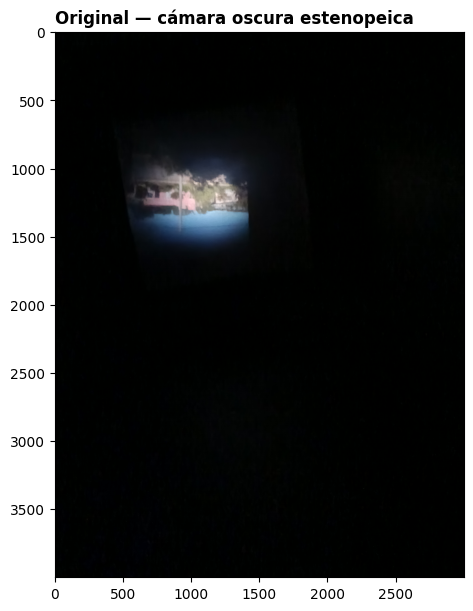

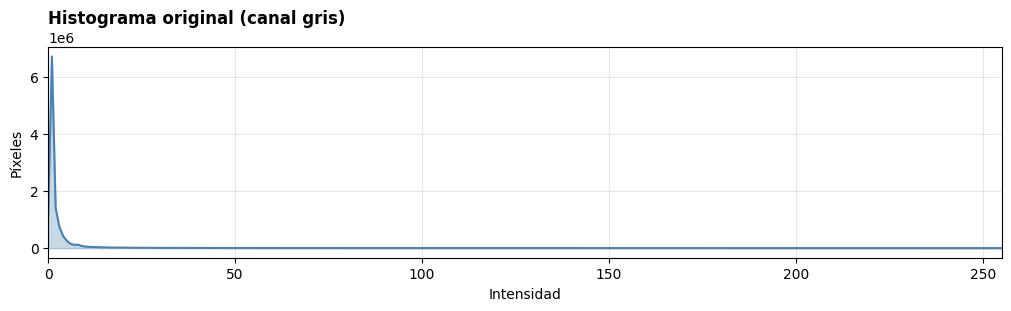

In [3]:
ruta = carpeta_originales / NOMBRE_IMAGEN
img_original = cargar_rgb(ruta)

h, w, c = img_original.shape
print(f"Tamaño original: {w} x {h} x {c}  (ancho × alto × canales)")

mostrar_imagen(img_original, "Original — cámara oscura estenopeica")
mostrar_histograma(img_original, "Histograma original (canal gris)")

In [5]:
# ── Diagnóstico e hipótesis ────────────────────────────────────────────────
diagnostico = (
    "La imagen está invertida a 180°. "
    "Presenta gran tamaño de  bordes oscuros producto del encuadre del dispositivo. "
    "El histograma muestra la mayoría de píxeles colapsados hacia intensidades bajas: "
    "bajo contraste global y ruido por escasez de luz en la captura."
)

hipotesis = (
    "Pipeline propuesto: "
    "1) Rotar 180° para corregir inversión. "
    "2) Recorte automático (umbralización + contorno mayor) para eliminar bordes negros. "
    "3) Suavizado bilateral (widget) para reducir ruido preservando bordes. "
    "4) Ecualización HSV sobre canal V para mejorar contraste sin alterar matiz ni saturación."
)

print("DIAGNÓSTICO:\n", diagnostico)
print("\nHIPÓTESIS:\n", hipotesis)

DIAGNÓSTICO:
 La imagen está invertida a 180°. Presenta gran tamaño de  bordes oscuros producto del encuadre del dispositivo. El histograma muestra la mayoría de píxeles colapsados hacia intensidades bajas: bajo contraste global y ruido por escasez de luz en la captura.

HIPÓTESIS:
 Pipeline propuesto: 1) Rotar 180° para corregir inversión. 2) Recorte automático (umbralización + contorno mayor) para eliminar bordes negros. 3) Suavizado bilateral (widget) para reducir ruido preservando bordes. 4) Ecualización HSV sobre canal V para mejorar contraste sin alterar matiz ni saturación.


---
## 3. Paso 1 — Rotación 180°

La cámara oscura proyecta la imagen invertida debido a la propagación rectilínea de la luz a través del orificio estenopeico.

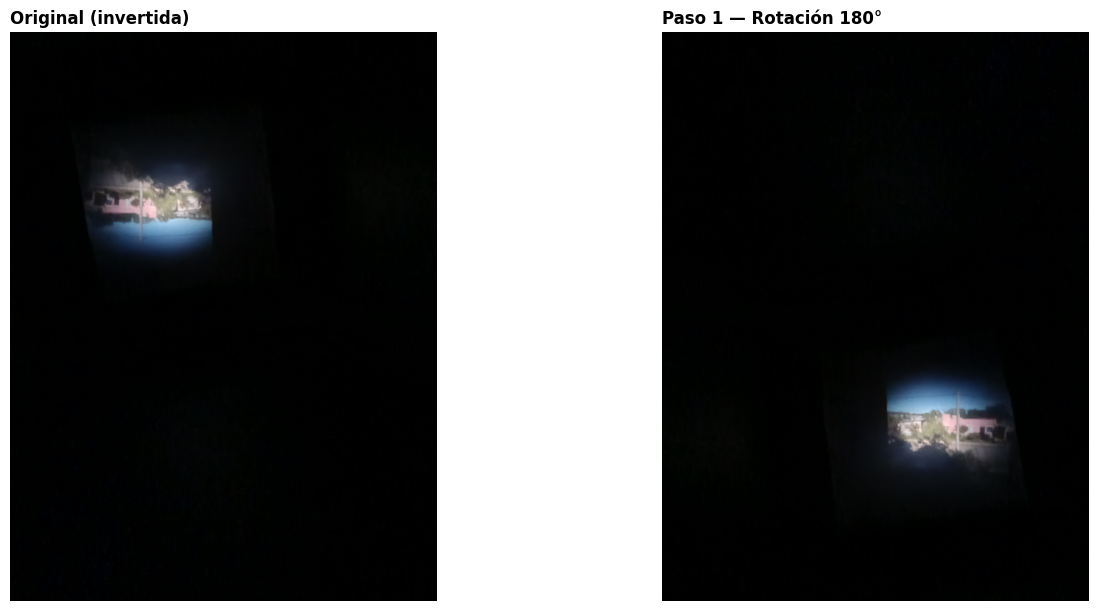

Rotación aplicada correctamente.


In [6]:
img_rotada = cv2.rotate(img_original, cv2.ROTATE_180)

mostrar_comparacion(
    img_original, img_rotada,
    "Original (invertida)", "Paso 1 — Rotación 180°"
)
print("Rotación aplicada correctamente.")

---
## 4. Paso 2 — Recorte automático de la región de interés (ROI)

Se binariza la imagen rotada con un umbral bajo para detectar la región iluminada,  
se busca el contorno de mayor área y se extrae su bounding box con un margen de seguridad.

Coordenadas del recorte: y=[2411:3107]  x=[1558:2490]
Tamaño después del recorte: 932 x 696


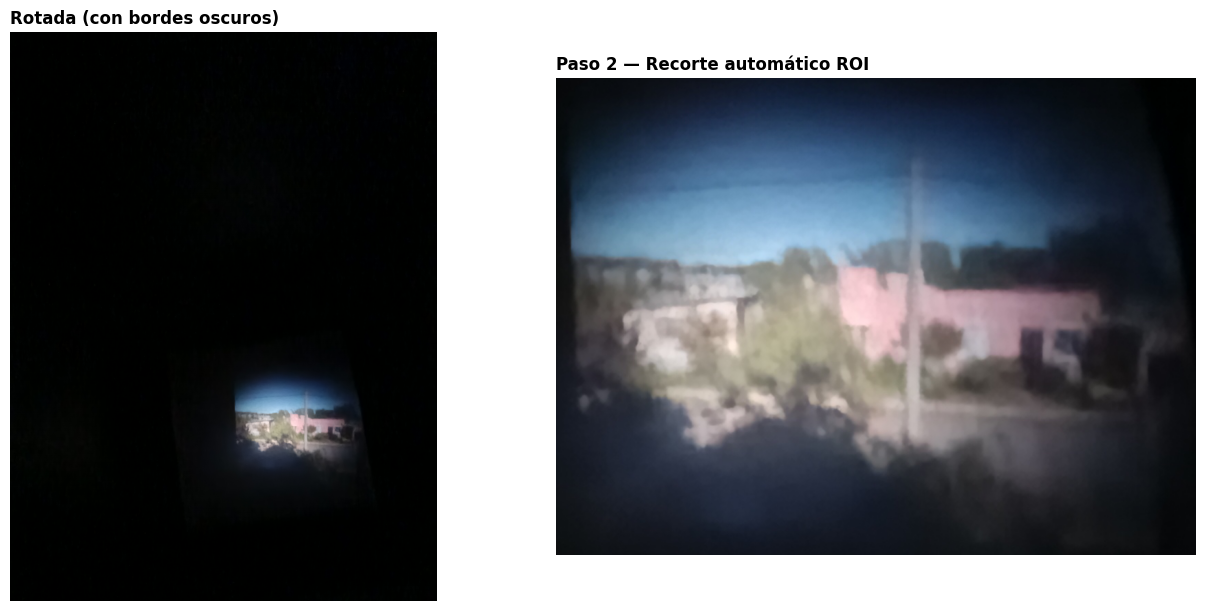

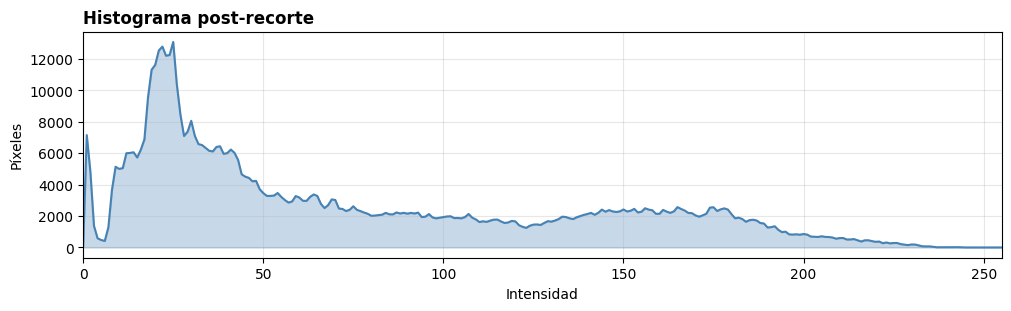

In [ ]:
def recorte_automatico(img_rgb, umbral_binario=30, margen=20):
    """
    Recorta la región útil de la imagen usando umbralización + contorno mayor.
    
    Parámetros
    ----------
    img_rgb         : imagen en RGB
    umbral_binario  : valor de corte para separar contenido de bordes negros (0–255)
    margen          : píxeles extra alrededor del bounding box detectado
    
    Retorna
    -------
    img_recortada   : imagen recortada en RGB
    (y1, y2, x1, x2): coordenadas del recorte aplicado
    """
    gris = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Binarización: píxeles con intensidad > umbral → región útil (blanco)
    _, mascara = cv2.threshold(gris, umbral_binario, 255, cv2.THRESH_BINARY)

    # Contorno más grande = región iluminada de la cámara oscura
    contornos, _ = cv2.findContours(
        mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contornos:
        print("⚠ No se detectaron contornos. Devolviendo imagen original.")
        return img_rgb, (0, img_rgb.shape[0], 0, img_rgb.shape[1])

    c_mayor = max(contornos, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c_mayor)

    # Aplicar margen con clipping para no salir de los límites
    H, W = img_rgb.shape[:2]
    y1 = max(0,     y - margen)
    y2 = min(H,     y + h + margen)
    x1 = max(0,     x - margen)
    x2 = min(W,     x + w + margen)

    return img_rgb[y1:y2, x1:x2].copy(), (y1, y2, x1, x2)


# ── Aplicar recorte ────────────────────────────────────────────────────────

img_recortada, coords = recorte_automatico(img_rotada, umbral_binario=30, margen=20)
y1, y2, x1, x2 = coords

print(f"Coordenadas del recorte: y=[{y1}:{y2}]  x=[{x1}:{x2}]")
print(f"Tamaño después del recorte: {img_recortada.shape[1]} x {img_recortada.shape[0]}")

mostrar_comparacion(
    img_rotada, img_recortada,
    "Rotada (con bordes oscuros)", "Paso 2 — Recorte automático ROI"
)
mostrar_histograma(img_recortada, "Histograma post-recorte")

---
## 5. Paso 3 — Suavizado bilateral (exploración con widget)

El filtro bilateral suaviza el ruido preservando los bordes porque combina  
cercanía espacial y similitud tonal. `sigmaColor` y `sigmaSpace` controlan  
cuánto peso se da a vecinos lejanos en intensidad o en posición.

In [ ]:
def explorar_bilateral(img):
    """Widget para explorar el parámetro sigma del filtro bilateral."""
    def _aplicar(sigma):
        filtrada = cv2.bilateralFilter(img, d=9, sigmaColor=sigma, sigmaSpace=sigma)
        fig, ejes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
        ejes[0].imshow(img)
        ejes[0].set_title("Sin suavizado", fontweight="bold", loc="left")
        ejes[0].axis("off")
        ejes[1].imshow(filtrada)
        ejes[1].set_title(f"Bilateral  sigma={sigma}", fontweight="bold", loc="left")
        ejes[1].axis("off")
        plt.show()

    interact(
        _aplicar,
        sigma=IntSlider(min=10, max=100, step=10, value=30, description="Sigma:")
    )

explorar_bilateral(img_recortada)

interactive(children=(IntSlider(value=30, description='Sigma:', min=10, step=10), Output()), _dom_classes=('wi…

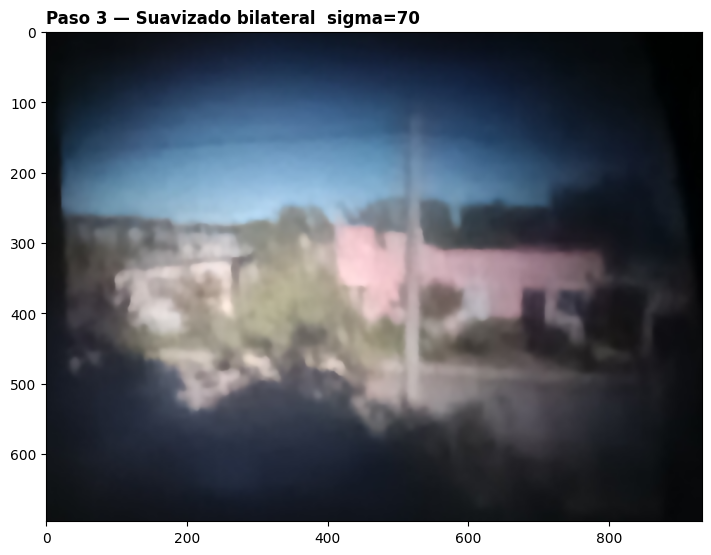

Sigma bilateral elegido: 70


In [ ]:
# ── Elegir sigma observado en el widget y aplicar ──────────────────────────
SIGMA_ELEGIDO = 70   

img_suavizada = cv2.bilateralFilter(
    img_recortada, d=9, # el tamaño del kernel se mantiene fijo
    sigmaColor=SIGMA_ELEGIDO,
    sigmaSpace=SIGMA_ELEGIDO
)

mostrar_imagen(img_suavizada, f"Paso 3 — Suavizado bilateral  sigma={SIGMA_ELEGIDO}")
print(f"Sigma bilateral elegido: {SIGMA_ELEGIDO}")

---
## 6. Paso 4 — Ecualización HSV (canal V)

### ¿Por qué se ecualiza el canal V y no RGB directamente?

Ecualizar los tres canales RGB por separado altera el balance de color porque  
modifica la relación entre R, G y B de forma independiente, produciendo  
cambios de matiz no deseados.  

Convertir a HSV y ecualizar solo el canal **V** (Valor/Brillo) permite mejorar  
el contraste lumínico **sin tocar el matiz (H) ni la saturación (S)**,  
preservando los colores originales de la escena.

Ecualización HSV aplicada.


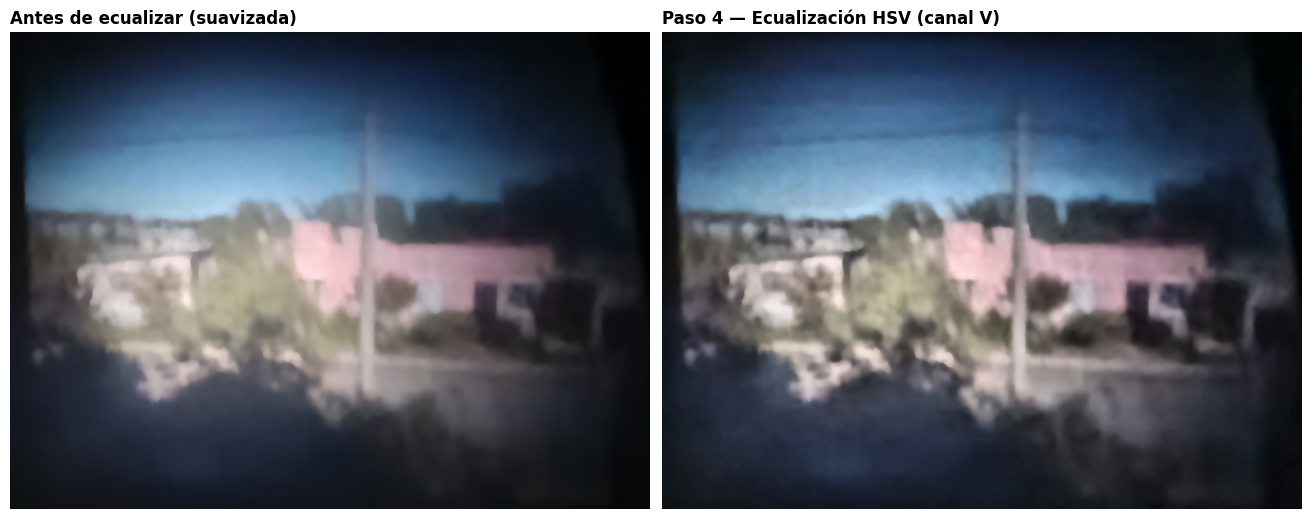

In [36]:
def ecualizacion_hsv(img_rgb):
    """
    Ecualiza el histograma únicamente sobre el canal V del espacio HSV.

    Proceso
    -------
    1. RGB → HSV
    2. Separar canales H, S, V
    3. Ecualizar canal V  (cv2.equalizeHist)
    4. Recomponer HSV y convertir a RGB

    Retorna
    -------
    img_ecualizada : imagen resultante en RGB
    h, s, v        : canal H original
    h, s, v_eq     : canal V ecualizado
    """
    # Paso 1 y 2: RGB → HSV y separar canales
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    canal_h, canal_s, canal_v = cv2.split(img_hsv)

    # Paso 3: ecualizar SOLO el canal V
    #canal_v_eq = cv2.equalizeHist(canal_v)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(16, 16))
    canal_v_eq = clahe.apply(canal_v)

    # Paso 4: recomponer y convertir de vuelta a RGB
    img_hsv_eq  = cv2.merge([canal_h, canal_s, canal_v_eq])
    img_eq_bgr  = cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2BGR)
    img_eq_rgb  = cv2.cvtColor(img_eq_bgr, cv2.COLOR_BGR2RGB)

    return img_eq_rgb, canal_h, canal_s, canal_v, canal_v_eq


img_ecualizada, ch, cs, cv_orig, cv_eq = ecualizacion_hsv(img_suavizada)

print("Ecualización HSV aplicada.")
mostrar_comparacion(
    img_suavizada, img_ecualizada,
    "Antes de ecualizar (suavizada)",
    "Paso 4 — Ecualización HSV (canal V)"
)

---
## 7. Comparación de histogramas: canal V antes y después

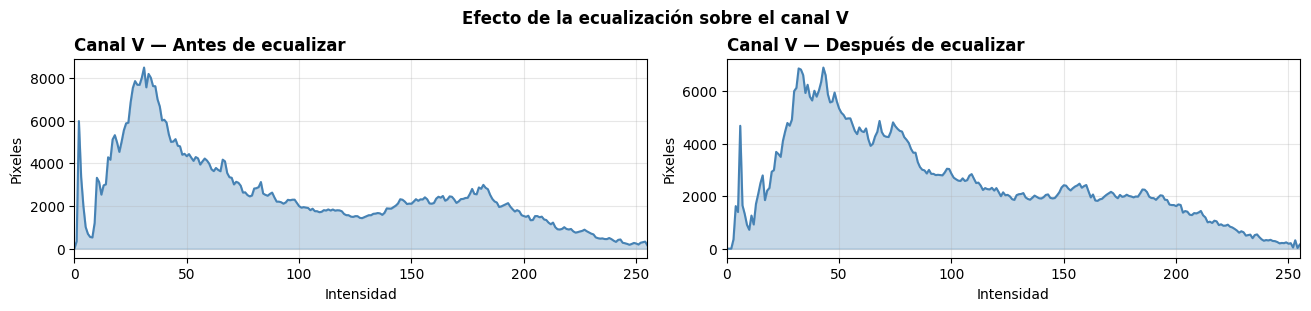

In [37]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 3), constrained_layout=True)

for ax, canal, titulo, color in zip(
    ejes,
    [cv_orig, cv_eq],
    ["Canal V — Antes de ecualizar", "Canal V — Después de ecualizar"],
    ["steelblue", "steelblue"]
):
    hist, bordes = np.histogram(canal.flatten(), bins=256, range=[0, 256])
    ax.plot(bordes[:-1], hist, color=color)
    ax.fill_between(bordes[:-1], hist, alpha=0.3, color=color)
    ax.set_title(titulo, fontweight="bold", loc="left")
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Píxeles")
    ax.set_xlim(0, 255)
    ax.grid(alpha=0.3)

plt.suptitle("Efecto de la ecualización sobre el canal V", fontweight="bold")
plt.show()

---
## 8. Visualización de canales H, S, V

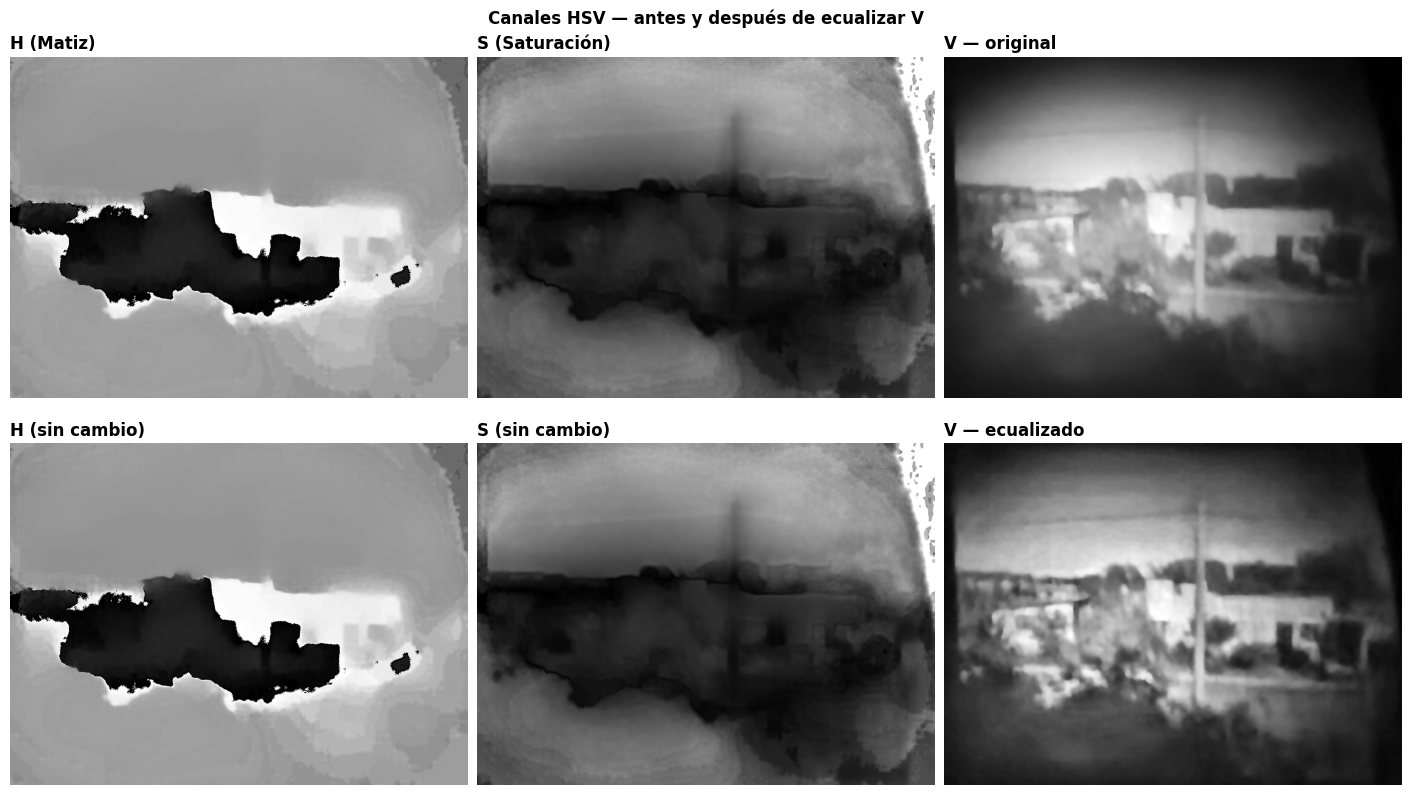

In [38]:
fig, ejes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
fig.suptitle("Canales HSV — antes y después de ecualizar V", fontweight="bold")

canales_orig  = [ch, cs, cv_orig]
nombres_orig  = ["H (Matiz)", "S (Saturación)", "V — original"]
canales_eq    = [ch, cs, cv_eq]
nombres_eq    = ["H (sin cambio)", "S (sin cambio)", "V — ecualizado"]

for i, (canal, nombre) in enumerate(zip(canales_orig, nombres_orig)):
    ejes[0, i].imshow(canal, cmap="gray")
    ejes[0, i].set_title(nombre, fontweight="bold", loc="left")
    ejes[0, i].axis("off")

for i, (canal, nombre) in enumerate(zip(canales_eq, nombres_eq)):
    ejes[1, i].imshow(canal, cmap="gray")
    ejes[1, i].set_title(nombre, fontweight="bold", loc="left")
    ejes[1, i].axis("off")

plt.show()

---
## 9. Resultado final — imagen completa del pipeline

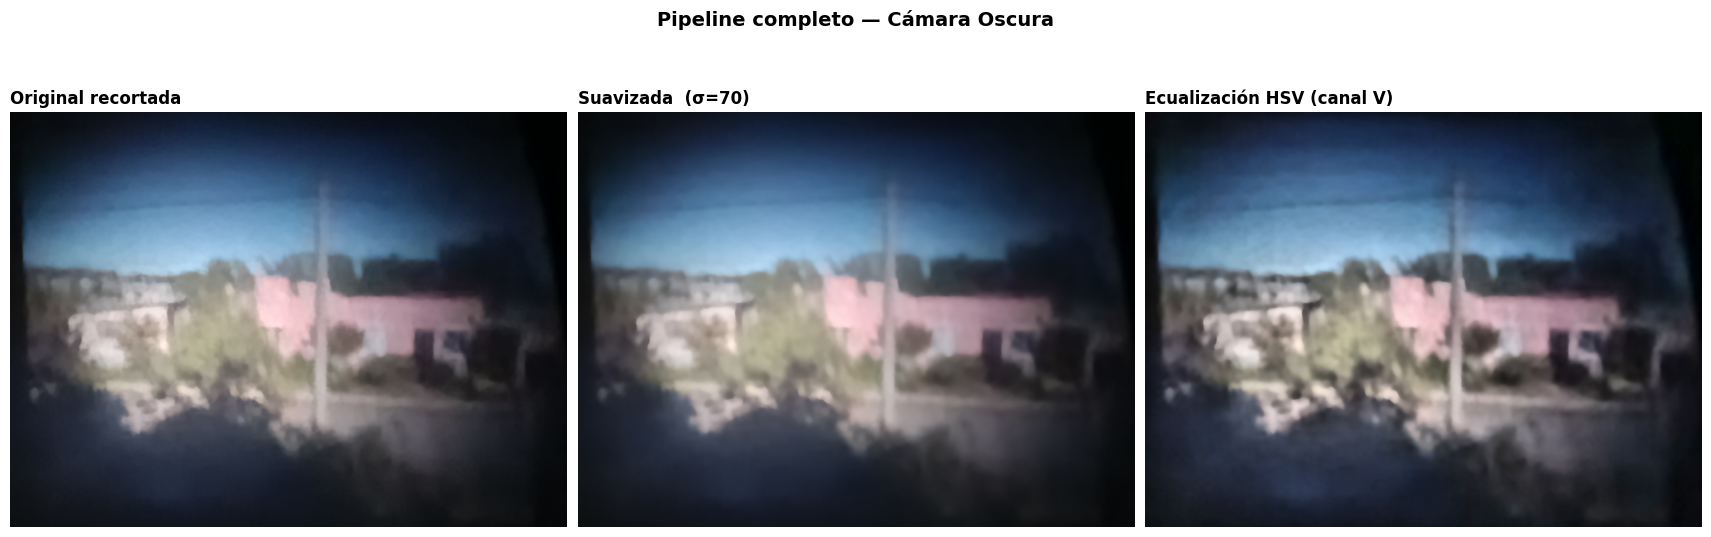

Imagen guardada en: /home/farfaneduardo/Documentos/Proyectos/farfan-eduardo-pdi-1c-2026/006/003 - LAB/imagenes/procesadas/camara_oscura_ecualizada.jpg


In [39]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)
fig.suptitle("Pipeline completo — Cámara Oscura", fontweight="bold", fontsize=14)

datos = [
    (img_recortada, "Original recortada"),
    (img_suavizada, f"Suavizada  (σ={SIGMA_ELEGIDO})"),
    (img_ecualizada, "Ecualización HSV (canal V)"),
]

for ax, (img, titulo) in zip(ejes, datos):
    ax.imshow(img)
    ax.set_title(titulo, fontweight="bold", loc="left")
    ax.axis("off")

plt.show()

# Guardar resultado
ruta_salida = carpeta_procesadas / "camara_oscura_ecualizada.jpg"
guardar_rgb(ruta_salida, img_ecualizada)
print(f"Imagen guardada en: {ruta_salida.resolve()}")

---
## 10. Análisis y reflexión

### ¿Qué mejoró visualmente?
La ecualización fue muy conservadora. El histograma post-ecualización mantiene la forma general del original pero con el pico levemente desplazado hacia intensidades más altas (~40), lo que se traduce en una mejora sutil del brillo en las zonas oscuras sin alterar las zonas ya iluminadas. La imagen gana algo de detalle en las sombras sin perder naturalidad.

### ¿Qué información se perdió?
Prácticamente no se perdió información. El límite bajo evita la amplificación agresiva, por lo que las zonas oscuras con ruido no se exageraron. La contrapartida es que la mejora de contraste es mínima: la imagen sigue siendo oscura en los extremos porque la limitación real está en la captura.

### ¿Qué limitaciones tiene la cámara oscura?
El orificio estenopeico limita la entrada de luz y no forma imágenes nítidas y juega un papel importante la distancia y la hora del día.
### ¿Por qué ecualizar el canal V y no RGB directamente?
Ecualizar R, G y B por separado rompe el equilibrio cromático porque cada canal se estira  
de forma independiente, produciendo cambios de matiz no deseados.  
Al trabajar en HSV y modificar solo **V**, el matiz y la saturación permanecen intactos  
y la imagen resultante mantiene los colores originales con mejor distribución tonal.

In [42]:
# ── Resumen en tabla de pandas ─────────────────────────────────────────────
import pandas as pd

resumen = pd.DataFrame({
    "Paso": ["Rotación 180°", "Recorte automático", "Suavizado bilateral", "Ecualización HSV"],
    "Operación": [
        "cv2.rotate(..., cv2.ROTATE_180)",
        "cv2.threshold → cv2.findContours → bounding box",
        f"cv2.bilateralFilter(d=9, sigma={SIGMA_ELEGIDO})",
        "BGR→HSV, split, clahe(V), merge, HSV→BGR"
    ],
    "Problema que resuelve": [
        "Inversión óptica de la cámara oscura",
        "Bordes negros del dispositivo fuera del ROI",
        "Ruido por escasez de luz en la captura",
        "Bajo contraste, histograma colapsado"
    ]
})

display(resumen)

,Paso,Operación,Problema que resuelve
0,Rotación 180°,"cv2.rotate(..., cv2.ROTATE_180)",Inversión óptica de la cámara oscura
1,Recorte automático,cv2.threshold → cv2.findContours → bounding box,Bordes negros del dispositivo fuera del ROI
2,Suavizado bilateral,"cv2.bilateralFilter(d=9, sigma=70)",Ruido por escasez de luz en la captura
3,Ecualización HSV,"BGR→HSV, split, clahe(V), merge, HSV→BGR","Bajo contraste, histograma colapsado"
